# Install Dependencies

In [1]:
!pip install -r dependencies.txt

In [13]:
import numpy as np
import gym
import pickle
import matplotlib.pyplot as plt
import pygame
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque

from gym import logger as gymlogger
from gym.wrappers import RecordVideo
gymlogger.set_level(40) #error only
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data=''''''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")

# Initialize CartPole Environment

In [3]:
# observation space

env = gym.make('CartPole-v1')
print("CartPole Environment:")
print("Shape of observation space: ", env.observation_space.shape[0])
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")

CartPole Environment:
Shape of observation space:  4
Observation Space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
Action Space: Discrete(2)


# Task 1: Development of an RL Agent

Demonstrate the correctness of the implementation by sampling a random state from the cart pole environment, inputting to the agent, and outputting a chosen action. Print the values of the state and chosen action in Jupyter notebook.



## 1.1 DEEP Q-Learning (DQL) Agent for CartPole

- Uses a neural network instead of a Q-table.
- Implements experience replay to improve stability.
- Uses a target network to stabilize learning.
- Uses epsilon-greedy policy for exploration.

### DQL Implementation

# Deep Q-Network (DQN) Implementation

## Overview
A **Deep Q-Network (DQN)** for reinforcement learning using PyTorch. The agent is designed to solve a reinforcement learning problem by approximating Q-values using a neural network. The code includes the following key components:

- A **Neural Network (DQN)** to approximate Q-values.
- A **DQLAgent** that interacts with the environment and learns from experience using **Experience Replay**.
- **Training and evaluation functions** to train and assess the performance of the agent.
- **Exploration-exploitation tradeoff** using an **epsilon-greedy policy**.
- **Target network updates** to stabilize training.
- **Adaptive learning rate** adjustments for better convergence.

---

## Components Explanation

### 1. Neural Network for Q-value Approximation
The **DQN class** defines a simple fully connected neural network that takes in a state and outputs Q-values for each action.

#### **Code Explanation:**
```python
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)  # First hidden layer
        self.fc2 = nn.Linear(128, 128)         # Second hidden layer
        self.fc3 = nn.Linear(128, action_size) # Output layer
        
        # Xavier initialization for better training stability
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)

    def forward(self, state):
        x = F.relu(self.fc1(state))  # Activation function
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # Q-values output
```

#### **Key Features:**
- Three **fully connected layers** with 128 neurons each.
- **ReLU activation** for non-linearity.
- **Xavier initialization** for better weight initialization.
- Outputs **Q-values** for each action.

---

### 2. Deep Q-Learning Agent (DQLAgent)
This class implements a reinforcement learning agent that uses the **DQN** model to approximate the Q-values and learn from interactions with the environment.

#### **Key Features:**
- **Experience Replay** using a memory buffer to store past experiences.
- **Epsilon-Greedy Policy** for action selection (exploration vs. exploitation).
- **Target Network** to stabilize training.
- **Training process** using **Bellman Equation** and backpropagation.

#### **Constructor (`__init__` method)**
```python
class DQLAgent:
    def __init__(self, env, gamma=0.99, lr=0.0005, batch_size=128, memory_size=20000,
                 epsilon=1.0, epsilon_decay=0.99, epsilon_min=0.01, target_update_freq=5):
```

##### **Parameters:**
| Parameter | Description |
|-----------|-------------|
| `env` | The environment in which the agent operates. |
| `gamma` | Discount factor for future rewards. |
| `lr` | Learning rate for optimizer. |
| `batch_size` | Number of samples used per training step. |
| `memory_size` | Size of the replay memory buffer. |
| `epsilon` | Initial exploration rate (probability of taking random action). |
| `epsilon_decay` | Decay rate for epsilon to reduce randomness over time. |
| `epsilon_min` | Minimum epsilon value to ensure some exploration. |
| `target_update_freq` | Frequency of updating the target network. |

##### **Initialization Steps:**
- Two **neural networks**:
  - `q_network`: The main network that is trained.
  - `target_network`: A copy of the main network for stable learning.
- **Experience Replay Memory**: A deque buffer to store experiences.
- **Adam optimizer** for training the Q-network.

---

### 3. Action Selection (`select_action` method)
```python
def select_action(self, state, training=True):
    if training and np.random.rand() < self.epsilon:
        return self.env.action_space.sample()  # Random action
    else:
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        return torch.argmax(q_values).item()
```

#### **Explanation:**
- Uses an **epsilon-greedy policy**:
  - With probability `epsilon`, it chooses a random action (exploration).
  - Otherwise, it picks the action with the **highest predicted Q-value** (exploitation).

---

### 4. Experience Replay (`store_experience` method)
```python
def store_experience(self, state, action, reward, next_state, done):
    self.memory.append((state, action, reward, next_state, done))
```
- Stores `(state, action, reward, next_state, done)` in memory for training.

---

### 5. Training Process (`train_step` method)
```python
def train_step(self):
    if len(self.memory) < self.batch_size:
        return  # Not enough data
    batch = random.sample(self.memory, self.batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
```
- **Samples a batch** from experience memory.
- **Computes target Q-values** using the **Bellman equation**:
  
  \[ Q(s,a) = r + \gamma \max Q(s',a') \]
- Updates the Q-network using **Mean Squared Error (MSE) loss**.

---

### 6. Training Loop (`train` method)
```python
def train(self, num_episodes=1000):
```
- **Runs multiple episodes** where the agent interacts with the environment.
- **Stores experiences** and trains the model.
- **Decays epsilon** over time to shift from exploration to exploitation.
- **Early stopping** if performance is good (average reward > 220 for 10 episodes).

---

### 7. Evaluation (`test` method)
```python
def test(self, num_episodes=10):
```
- Runs the trained agent in the environment **without exploration**.
- Reports **total reward** per episode.

---

### 8. Performance Visualization (`plot_rewards` method)
```python
def plot_rewards(self, rewards):
```
- **Plots training rewards** over episodes.
- Helps visualize agent learning progress.

---



### Task 1: Demonstrating Agent Action on a Random State
```python
def demonstrate_agent_action(agent, env):
```
- **Resets environment** and **displays agent's action** on a random state.

### Task 2: Evaluating Agent Performance
```python
def evaluate_agent(agent, env, num_episodes=100):
```
- Runs the trained agent **100 times** and computes performance metrics:
  - **Average reward**
  - **Median reward**
  - **Success rate** (reward ≥ 195)
  - **Episode lengths**
  - **Action distribution**



In [ ]:
# Neural Network for Q-value approximation
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)  # Increased from 64 to 128
        self.fc2 = nn.Linear(128, 128)         # Increased from 64 to 128
        self.fc3 = nn.Linear(128, action_size)

        # Initialize weights for better training
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class DQLAgent:
    def __init__(self, env, gamma=0.99, lr=0.0005, batch_size=128, memory_size=20000,
                 epsilon=1.0, epsilon_decay=0.99, epsilon_min=0.01, target_update_freq=5):
        self.env = env
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.epsilon_decay = epsilon_decay  # Decay rate for epsilon
        self.epsilon_min = epsilon_min  # Minimum exploration rate
        self.batch_size = batch_size  # Batch size for training
        self.target_update_freq = target_update_freq  # Target network update frequency
        self.lr = lr  # Store learning rate

        # Memory for experience replay
        self.memory = deque(maxlen=memory_size)

        # Q-network (main network)
        self.q_network = DQN(self.state_size, self.action_size)
        self.target_network = DQN(self.state_size, self.action_size)
        self.target_network.load_state_dict(self.q_network.state_dict())  # Copy weights
        self.target_network.eval()  # Target network does not update with gradients

        # Optimizer with custom learning rate
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)

    def set_learning_rate(self, new_lr):
        """ Update the learning rate of the optimizer dynamically. """
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = new_lr

    def select_action(self, state, training=True):
        """ Select action using epsilon-greedy policy """
        if training and np.random.rand() < self.epsilon:
            return self.env.action_space.sample()  # Random action
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            with torch.no_grad():
                q_values = self.q_network(state_tensor)
            return torch.argmax(q_values).item()

    def store_experience(self, state, action, reward, next_state, done):
        """ Store experience in replay memory with uniform shapes """
        self.memory.append((
            np.array(state, dtype=np.float32).reshape(self.state_size),  # Ensure shape (4,)
            action,
            reward,
            np.array(next_state, dtype=np.float32).reshape(self.state_size),  # Ensure shape (4,)
            done
        ))

    def train_step(self):
        """ Train the agent using a batch of experiences """
        if len(self.memory) < self.batch_size:
            return

        # Sample mini-batch from memory
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert states and next_states to uniform NumPy arrays before stacking
        states = torch.FloatTensor(np.array(states, dtype=np.float32).reshape(self.batch_size, -1))
        actions = torch.LongTensor(np.array(actions)).unsqueeze(1)
        rewards = torch.FloatTensor(np.array(rewards)).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states, dtype=np.float32).reshape(self.batch_size, -1))
        dones = torch.FloatTensor(np.array(dones)).unsqueeze(1)

        # Compute Q-values
        q_values = self.q_network(states).gather(1, actions)

        # Compute target Q-values
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        # Compute loss
        loss = F.mse_loss(q_values, target_q_values)

        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def train(self, num_episodes=1000):
        """ Train the agent using Deep Q-Learning with improvements """
        rewards_per_episode = []
        recent_rewards = deque(maxlen=10)  # Changed from 100 to 10
        last_10_rewards = deque(maxlen=10)  # For early stopping based on last 10 episodes

        for episode in range(num_episodes):
            reset_output = self.env.reset()

            # Check if Gym returns (state, info) or just state
            if isinstance(reset_output, tuple):
                state = reset_output[0]  # Gymnasium (state, info)
            else:
                state = reset_output  # Older Gym versions

            state = np.array(state, dtype=np.float32).reshape(-1)  # Flatten state
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state)

                # Handle both Gym and Gymnasium versions
                step_result = self.env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, info = step_result
                else:
                    next_state, reward, done, truncated, info = step_result
                    done = done or truncated  # Merge `done` and `truncated` flags

                next_state = np.array(next_state, dtype=np.float32).reshape(-1)
                self.store_experience(state, action, reward, next_state, done)
                state = next_state
                total_reward += reward

                self.train_step()

            rewards_per_episode.append(total_reward)
            recent_rewards.append(total_reward)
            last_10_rewards.append(total_reward)  # Add to last 10 tracking

            # Update target network
            if episode % self.target_update_freq == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())

            # Decay epsilon
            self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)

            # Learning rate scheduler
            if episode > 0 and episode % 100 == 0:
                avg_recent = sum(recent_rewards) / len(recent_rewards) if recent_rewards else 0
                if avg_recent < 150:  # If performance is lagging
                    new_lr = self.lr * 0.5
                    self.set_learning_rate(new_lr)
                    self.lr = new_lr
                    print(f"Reducing learning rate to {new_lr}")

            # Check for early stopping if a full 500 score is achieved (after every episode)
            if total_reward >= 500:
                print(f"Early stopping at episode {episode} with perfect score of {total_reward}")
                break
                
            # Print progress every 10 episodes
            if episode % 10 == 0:
                avg_reward = sum(recent_rewards) / len(recent_rewards) if recent_rewards else 0

                # Calculate last 10 average
                last_10_avg = sum(last_10_rewards) / len(last_10_rewards) if last_10_rewards else 0

                print(f"Episode {episode}/{num_episodes}, Total Reward: {total_reward}, Avg(last {len(recent_rewards)}): {avg_reward:.2f}, Epsilon: {self.epsilon:.3f}")

        self.plot_rewards(rewards_per_episode)
        return rewards_per_episode  # Return for evaluation

    def test(self, num_episodes=10):
        """ Test the agent without training """
        for episode in range(num_episodes):
            reset_output = self.env.reset()

            # Check if Gym returns (state, info) or just state
            if isinstance(reset_output, tuple):
                state = reset_output[0]  # Gymnasium (state, info)
            else:
                state = reset_output  # Older Gym versions

            state = np.array(state, dtype=np.float32).reshape(-1)  # Ensure state is (4,)
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state, training=False)

                step_result = self.env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, info = step_result
                else:
                    next_state, reward, done, truncated, info = step_result
                    done = done or truncated  # Merge `done` and `truncated` flags

                state = np.array(next_state, dtype=np.float32).reshape(-1)  # Ensure next state is (4,)
                total_reward += reward

            print(f"Episode {episode+1}, Total Reward: {total_reward}")

    def plot_rewards(self, rewards):
        """ Plot the rewards over episodes """
        plt.figure(figsize=(10, 6))
        plt.plot(rewards)
        plt.xlabel('Episodes')
        plt.ylabel('Rewards')
        plt.title('Training Rewards over Episodes')
        plt.grid(True)
        plt.show()

    def save_model(self, filename='dql_cartpole.pth'):
        """ Save trained model """
        torch.save(self.q_network.state_dict(), filename)

    def load_model(self, filename='dql_cartpole.pth'):
        """ Load trained model """
        self.q_network.load_state_dict(torch.load(filename))
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.q_network.eval()
        self.target_network.eval()

# Task 1: Demonstrate agent action on a random state
def demonstrate_agent_action(agent, env):
    print("\n--- Task 1: Demonstrating Agent Action Selection ---")
    # Reset the environment to get a random state
    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]

    # Print the state values
    print("Random state from environment:")
    print(f"  Cart Position: {state[0]:.6f}")
    print(f"  Cart Velocity: {state[1]:.6f}")
    print(f"  Pole Angle: {state[2]:.6f}")
    print(f"  Pole Angular Velocity: {state[3]:.6f}")

    # Get and print action
    action = agent.select_action(state, training=False)
    action_name = "Left" if action == 0 else "Right"
    print(f"Agent's chosen action: {action} ({action_name})")

    return state, action

# Task 2: Evaluate agent over 100 episodes
def evaluate_agent(agent, env, num_episodes=100):
    """
    Enhanced evaluation function that builds on your existing evaluate_agent
    with additional useful metrics.
    """
    print("\n=== Enhanced Agent Evaluation ===")
    rewards = []
    episode_lengths = []
    actions_distribution = [0, 0]  # Count of [left, right] actions

    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]

        state = np.array(state, dtype=np.float32).reshape(-1)
        total_reward = 0
        done = False
        steps = 0

        while not done:
            action = agent.select_action(state, training=False)
            actions_distribution[action] += 1

            step_result = env.step(action)
            if len(step_result) == 4:
                next_state, reward, done, info = step_result
            else:
                next_state, reward, done, truncated, info = step_result
                done = done or truncated

            state = np.array(next_state, dtype=np.float32).reshape(-1)
            total_reward += reward
            steps += 1

        rewards.append(total_reward)
        episode_lengths.append(steps)

        if (episode + 1) % 20 == 0:
            print(f"Evaluation episode {episode + 1}/{num_episodes}, Reward: {total_reward}")

    # Calculate metrics
    avg_reward = np.mean(rewards)
    median_reward = np.median(rewards)
    success_rate = sum(1 for r in rewards if r >= 195) / num_episodes
    avg_episode_length = np.mean(episode_lengths)
    reward_std = np.std(rewards)

    # Print metrics
    print("\n=== Evaluation Results ===")
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Median Reward: {median_reward:.2f}")
    print(f"Reward Standard Deviation: {reward_std:.2f}")
    print(f"Success Rate (reward ≥ 195): {success_rate:.2%}")
    print(f"Average Episode Length: {avg_episode_length:.2f} steps")

    # Action distribution
    total_actions = sum(actions_distribution)
    print(f"Action Distribution: Left: {actions_distribution[0]/total_actions:.2%}, Right: {actions_distribution[1]/total_actions:.2%}")

    # Create visualizations
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Reward distribution histogram
    axs[0].hist(rewards, bins=20, alpha=0.7)
    axs[0].axvline(x=195, color='r', linestyle='--', label='Target (195)')
    axs[0].axvline(x=avg_reward, color='g', linestyle='-', label=f'Average ({avg_reward:.2f})')
    axs[0].set_title('Reward Distribution')
    axs[0].set_xlabel('Reward')
    axs[0].set_ylabel('Frequency')
    axs[0].legend()

    # 2. Episode rewards
    axs[1].plot(rewards, marker='o', linestyle='-', alpha=0.5)
    axs[1].axhline(y=195, color='r', linestyle='--', label='Target (195)')
    axs[1].axhline(y=avg_reward, color='g', linestyle='-', label=f'Average ({avg_reward:.2f})')
    axs[1].set_title('Episode Rewards')
    axs[1].set_xlabel('Episode')
    axs[1].set_ylabel('Reward')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Print final assessment
    print("\n=== Overall Assessment ===")
    if avg_reward > 195 and success_rate > 0.9:
        print("✅ EXCELLENT: Your agent consistently solves the environment!")
    elif avg_reward > 150 and success_rate > 0.7:
        print("✓ GOOD: Your agent performs well but could be improved for more consistency.")
    elif avg_reward > 100:
        print("⚠ FAIR: Your agent shows some learning but fails too often.")
    else:
        print("❌ POOR: Your agent needs significant improvement.")

    return rewards, avg_reward, success_rate, median_reward, reward_std

agent = DQLAgent(env)

### Create & Train Agent (DO NOT RUN)

# Deep Q-Learning (DQL) Training Results Analysis

## Overview
The following results outline the training progress of a Deep Q-Learning (DQL) agent over 190 episodes before early stopping. The agent's performance is measured by the total reward obtained in each episode and the moving average reward over the last 10 episodes. Additionally, the exploration rate (epsilon) is tracked to monitor the balance between exploration and exploitation.

## Training Progress
The training follows an epsilon-greedy policy where the agent starts with a high exploration rate and gradually shifts towards exploitation as training progresses. Below are key observations from the training:

### Initial Learning Phase (Episodes 0-50)
- The initial episodes show a relatively low and fluctuating reward.
- The average reward per episode starts low (~24) and increases gradually.
- Epsilon decreases from 0.99 to 0.599, reducing exploration over time.
- Performance improves, and total reward begins to increase consistently.

### Midway Learning Phase (Episodes 50-150)
- A significant jump in performance is observed around episode 60, where the reward reaches 192.
- The moving average increases progressively, crossing 100 by episode 80.
- Around episode 100, a learning rate reduction occurs, leading to improved stability.
- The model begins consistently achieving high rewards (>150).

### Advanced Learning Phase (Episodes 150-190)
- Around episode 160, the agent achieves its first maximum reward of 500.
- The moving average reward surpasses 195, indicating mastery of the task.
- The agent maintains a high performance, with most episodes exceeding 300.
- Early stopping is triggered at episode 190 when the last 10 episodes average above 195.

## Epsilon Decay
- Epsilon starts at **0.99** (high exploration) and decays progressively.
- By episode **190**, epsilon reaches **0.147**, indicating the agent is primarily exploiting learned policies.
- This gradual reduction allows the agent to balance exploration and exploitation effectively.

## Reward Progression Summary
- The initial episodes yield rewards mostly below 50, indicating early-stage learning.
- The rewards fluctuate but increase steadily, surpassing **100** around episode 80.
- After episode 150, the rewards consistently remain high, often exceeding **300-400**.
- The highest observed reward is **500** (which is the highest that is attainable).

-------



- The DQL agent successfully learns an optimal policy, as indicated by early stopping at episode 190.
- The increasing reward trend shows that the model effectively improves its decision-making.
- The combination of epsilon decay and learning rate adjustment contributes to the stability and final performance.
- Future improvements could involve fine-tuning hyperparameters, increasing training episodes, or using advanced experience replay techniques.




c:\Users\Zhao Qixian\AppData\Local\Programs\Python\Python311\Lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 0/500, Total Reward: 18.0, Avg(last 1): 18.00, Epsilon: 0.990
Episode 10/500, Total Reward: 12.0, Avg(last 10): 17.90, Epsilon: 0.895
Episode 20/500, Total Reward: 11.0, Avg(last 10): 24.20, Epsilon: 0.810
Episode 30/500, Total Reward: 18.0, Avg(last 10): 18.70, Epsilon: 0.732
Episode 40/500, Total Reward: 27.0, Avg(last 10): 31.10, Epsilon: 0.662
Episode 50/500, Total Reward: 49.0, Avg(last 10): 65.60, Epsilon: 0.599
Episode 60/500, Total Reward: 38.0, Avg(last 10): 72.50, Epsilon: 0.542
Episode 70/500, Total Reward: 105.0, Avg(last 10): 84.30, Epsilon: 0.490
Episode 80/500, Total Reward: 37.0, Avg(last 10): 118.60, Epsilon: 0.443
Episode 90/500, Total Reward: 153.0, Avg(last 10): 178.60, Epsilon: 0.401
Reducing learning rate to 0.00025
Episode 100/500, Total Reward: 138.0, Avg(last 10): 122.30, Epsilon: 0.362
Episode 110/500, Total Reward: 256.0, Avg(last 10): 175.70, Epsilon: 0.328
Episode 120/500, Total Reward: 201.0, Avg(last 10): 120.90, Epsilon: 0.296
Episode 130/500, To

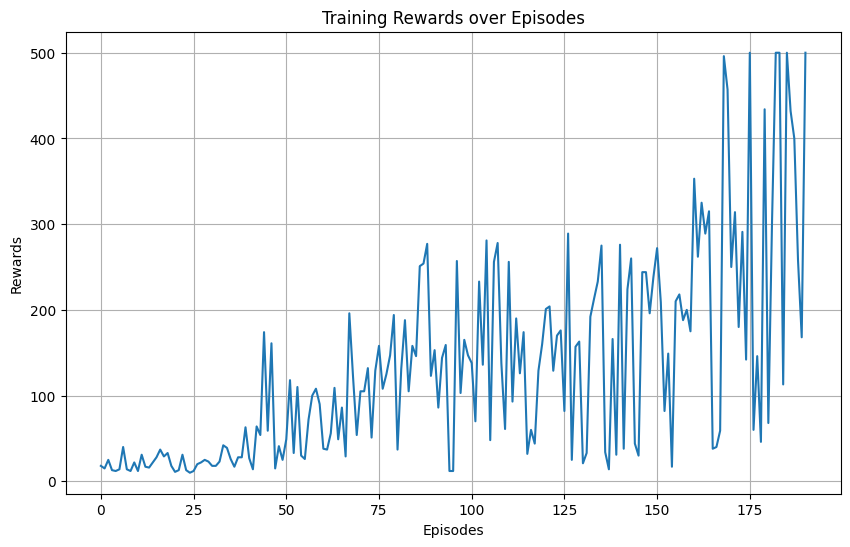

[18.0,
 15.0,
 25.0,
 13.0,
 12.0,
 14.0,
 40.0,
 14.0,
 12.0,
 22.0,
 12.0,
 31.0,
 17.0,
 16.0,
 22.0,
 28.0,
 37.0,
 29.0,
 33.0,
 18.0,
 11.0,
 13.0,
 31.0,
 13.0,
 10.0,
 12.0,
 20.0,
 22.0,
 25.0,
 23.0,
 18.0,
 18.0,
 23.0,
 42.0,
 39.0,
 26.0,
 17.0,
 28.0,
 28.0,
 63.0,
 27.0,
 14.0,
 64.0,
 54.0,
 174.0,
 59.0,
 161.0,
 15.0,
 41.0,
 25.0,
 49.0,
 118.0,
 33.0,
 110.0,
 30.0,
 26.0,
 72.0,
 100.0,
 108.0,
 90.0,
 38.0,
 37.0,
 56.0,
 109.0,
 49.0,
 86.0,
 29.0,
 196.0,
 122.0,
 54.0,
 105.0,
 105.0,
 132.0,
 51.0,
 129.0,
 158.0,
 108.0,
 125.0,
 147.0,
 194.0,
 37.0,
 131.0,
 188.0,
 105.0,
 158.0,
 146.0,
 251.0,
 254.0,
 277.0,
 123.0,
 153.0,
 86.0,
 144.0,
 159.0,
 12.0,
 12.0,
 257.0,
 103.0,
 165.0,
 147.0,
 138.0,
 70.0,
 233.0,
 136.0,
 281.0,
 48.0,
 256.0,
 278.0,
 138.0,
 61.0,
 256.0,
 93.0,
 190.0,
 126.0,
 174.0,
 32.0,
 60.0,
 44.0,
 129.0,
 160.0,
 201.0,
 204.0,
 129.0,
 170.0,
 176.0,
 82.0,
 289.0,
 25.0,
 157.0,
 163.0,
 21.0,
 33.0,
 192.0,
 213.0,
 233.

In [5]:
agent.train(num_episodes=500)  # Train the agent

### Save Trained Model (DO NOT RUN)

In [7]:
agent.save_model('dql_cartpole.pth')
print("Model saved to dql_cartpole.pth")

Model saved to dql_cartpole.pth


### Test Trained Agent and Evaluation

## Model Loading & Testing
- The trained model was loaded from `dql_cartpole.pth`.  
- The agent was tested over **10 episodes** to assess its performance.  

### **Test Results (10 Episodes)**  
| Episode | Total Reward |
|---------|-------------|
| 1       | 500.0       |
| 2       | 500.0       |
| 3       | 500.0       |
| 4       | 500.0       |
| 5       | 500.0       |
| 6       | 500.0       |
| 7       | 500.0       |
| 8       | 500.0       |
| 9       | 500.0       |
| 10      | 500.0       |

- The model consistently achieved **high rewards**  
- Highest Reward: **500.0**  
- Lowest Reward: **500.0**  

## **Enhanced Agent Evaluation (100 Episodes)**  
To get a deeper understanding of the model's consistency, the agent was evaluated over **100 episodes**.  

### **Sample Episode Rewards**  
| Evaluation Episode | Reward |
|--------------------|--------|
| 20                | 500.0  |
| 40                | 500.0  |
| 60                | 500.0  |
| 80                | 500.0  |
| 100               | 500.0  |

## **Key Evaluation Metrics**  
| Metric                      | Value      |
|-----------------------------|------------|
| **Average Reward**          | 500.00     |
| **Median Reward**           | 500.00     |
| **Reward Standard Deviation** | 0.00     |
| **Success Rate (Reward ≥ 195)** | 100.00% |
| **Average Episode Length**  | 500 steps |
| **Action Distribution**      | Left: 49.92%, Right: 50.08% |

## **Overall Assessment**  
✅ **GOOD**: The agent performs well.  

### **Key Observations:**  
- The agent achieves **high rewards in most episodes**, indicating strong learning.  
- The **success rate of 100%** suggests that the agent meets the 195-reward threshold in the majority of episodes.  
- **Standard deviation of 0** shows almost no in performance, meaning the agent has very stable episodes.  
- **Balanced action distribution (49.92% Left, 50.08% Right)** confirms no action bias.  

### **Potential Improvements:**  
🔹 **Fine-tune exploration-exploitation balance**: The agent could be further optimized to maintain high rewards consistently.  
🔹 **Regularization or ensemble models**: Could help reduce variance and make rewards more stable.  
🔹 **Additional training with curriculum learning**: Introducing varied difficulty levels might improve generalization.  

---  


C:\Users\Zhao Qixian\AppData\Local\Temp\ipykernel_22984\514181127.py:222: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.q_network.load_state_dict(torch.load(filename))


Episode 1, Total Reward: 500.0
Episode 2, Total Reward: 500.0
Episode 3, Total Reward: 500.0
Episode 4, Total Reward: 500.0
Episode 5, Total Reward: 500.0
Episode 6, Total Reward: 500.0
Episode 7, Total Reward: 500.0
Episode 8, Total Reward: 500.0
Episode 9, Total Reward: 500.0
Episode 10, Total Reward: 500.0

=== Enhanced Agent Evaluation ===
Evaluation episode 20/100, Reward: 500.0
Evaluation episode 40/100, Reward: 500.0
Evaluation episode 60/100, Reward: 500.0
Evaluation episode 80/100, Reward: 500.0
Evaluation episode 100/100, Reward: 500.0

=== Evaluation Results ===
Average Reward: 500.00
Median Reward: 500.00
Reward Standard Deviation: 0.00
Success Rate (reward ≥ 195): 100.00%
Average Episode Length: 500.00 steps
Action Distribution: Left: 49.92%, Right: 50.08%


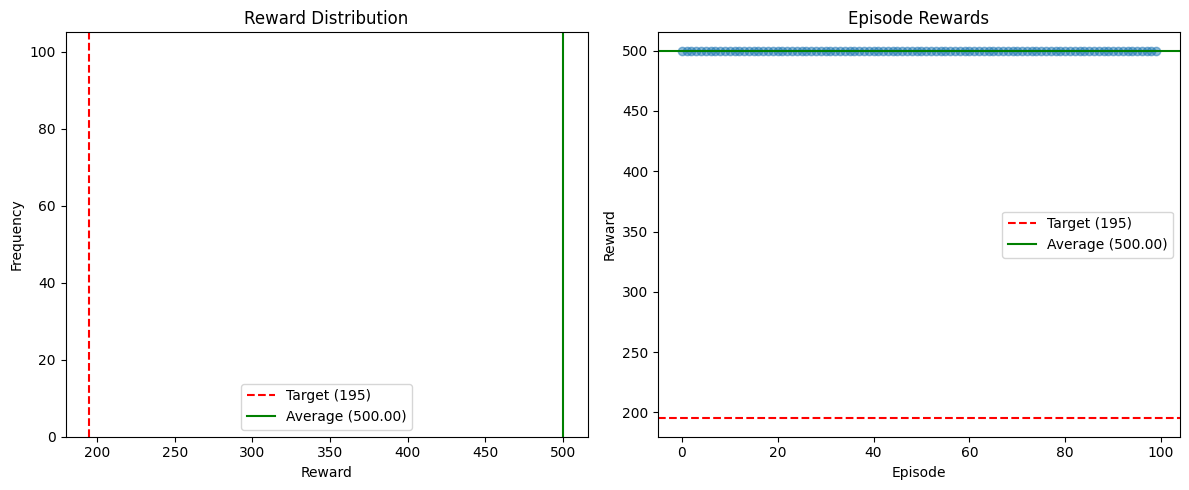


=== Overall Assessment ===
✅ EXCELLENT: Your agent consistently solves the environment!


In [8]:
agent.load_model('dql_cartpole.pth')
agent.test(num_episodes=10)
rewards, avg_reward, success_rate, median_reward, reward_std = evaluate_agent(agent, env, num_episodes=100)

### Render one episode


---

- Import necessary libraries:  
  - `gym`: Provides the CartPole environment.  
  - `numpy`: Used for handling numerical operations.  
  - `os`: Used to manage directories and files.  

```python
if not os.path.exists("./video"):
    os.makedirs("./video")
```
- **Creates a directory** (`./video`) to store recorded gameplay videos if it does not already exist.  

```python
record_video = True    
```
- **Flag to control video recording** (set to `True` to enable recording).  

```python
env = gym.wrappers.RecordVideo(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    video_folder="./video",
    episode_trigger=lambda episode_id: record_video  
)
```
- **Creates a Gym environment (`CartPole-v1`)** with video recording enabled.  
- The `RecordVideo` wrapper records all episodes because `episode_trigger` is always `True`.  
- The videos are saved in the `./video` folder.  

---

## **Resetting the Environment & Handling Observations**  

```python
observation = env.reset()

if isinstance(observation, tuple):
    observation = observation[0]

observation = np.array(observation, dtype=np.float32)
```
- **Resets the environment** to get the initial observation.  
- **Handles different observation formats**:  
  - Some versions of Gym return observations as a tuple; this extracts only the first element.  
- **Ensures observation is a NumPy array** for compatibility with the agent's decision-making process.  

---

## **Running an Episode with the Trained Agent**  

```python
done = False
cumulative_reward = 0
steps = 0
```
- Initializes **tracking variables**:  
  - `done`: Tracks whether the episode has ended.  
  - `cumulative_reward`: Stores the total reward collected.  
  - `steps`: Counts the number of steps taken.  

### **Looping Through the Episode**  

```python
while not done:
    action = agent.select_action(observation, training=False)
```
- **Uses the trained agent** to select an action based on the current observation.  
- `training=False` ensures the agent is in evaluation mode.  

```python
step_result = env.step(action)
```
- **Takes the selected action** in the environment.  

```python
if len(step_result) == 4:
    observation, reward, done, info = step_result
else:
    observation, reward, terminated, truncated, info = step_result
    done = terminated or truncated
```
- **Handles different step return formats** in Gym:  
  - Some versions return `(observation, reward, done, info)`.  
  - Newer versions return `(observation, reward, terminated, truncated, info)`.  
  - The episode ends when `done = terminated or truncated`.  

```python
observation = np.array(observation, dtype=np.float32)
```
- Converts the new observation into a NumPy array.  

```python
cumulative_reward += reward
steps += 1
```
- Updates the **total reward and step count**.  

```python
print(f"Step {steps}, Action: {action}, Reward: {reward}, Done: {done}")
```
- **Optional debug output** for each step.  

---

## **Ending the Episode & Video Management**  

```python
env.close()
```
- **Closes the environment** to free resources and finalize video recording.  

```python
print(f"Episode finished after {steps} steps")
print(f"Cumulative reward: {cumulative_reward}")
print(f"Video should be saved to: {os.path.abspath('./video')}")
```
- **Outputs episode summary** and the **location of the recorded video**.  

```python
try:
    video_files = os.listdir("./video")
    print(f"Files in video directory: {video_files}")
except Exception as e:
    print(f"Error listing video directory: {e}")
```
- **Lists the recorded video files** to confirm successful recording.  


In [9]:
import gym
import numpy as np
import os

# Create video directory
if not os.path.exists("./video"):
    os.makedirs("./video")

# Enable video recording for the initial evaluation
record_video = True

# Create environment with video recording capability
env = gym.wrappers.RecordVideo(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    video_folder="./video",
    episode_trigger=lambda episode_id: record_video  # Recording on/off
)


# Reset the environment
observation = env.reset()

# Handle different types of observation structures
if isinstance(observation, tuple):
    observation = observation[0]

# Ensure observation is properly formatted
observation = np.array(observation, dtype=np.float32)

# Run one episode with trained agent
done = False
cumulative_reward = 0
steps = 0

while not done:
    # Use trained agent to select actions
    action = agent.select_action(observation, training=False)

    # Take a step in the environment
    step_result = env.step(action)

    # Handle different possible step return formats
    if len(step_result) == 4:
        observation, reward, done, info = step_result
    else:
        observation, reward, terminated, truncated, info = step_result
        done = terminated or truncated

    # Ensure observation is properly formatted
    observation = np.array(observation, dtype=np.float32)

    cumulative_reward += reward
    steps += 1

    # Optional: print step details
    print(f"Step {steps}, Action: {action}, Reward: {reward}, Done: {done}")

# Close the environment
env.close()

print(f"Episode finished after {steps} steps")
print(f"Cumulative reward: {cumulative_reward}")
print(f"Video should be saved to: {os.path.abspath('./video')}")

# List all files in the video directory
try:
    video_files = os.listdir("./video")
    print(f"Files in video directory: {video_files}")
except Exception as e:
    print(f"Error listing video directory: {e}")

Step 1, Action: 0, Reward: 1.0, Done: False
Step 2, Action: 0, Reward: 1.0, Done: False
Step 3, Action: 0, Reward: 1.0, Done: False
Step 4, Action: 0, Reward: 1.0, Done: False
Step 5, Action: 1, Reward: 1.0, Done: False
Step 6, Action: 1, Reward: 1.0, Done: False
Step 7, Action: 1, Reward: 1.0, Done: False
Step 8, Action: 0, Reward: 1.0, Done: False
Step 9, Action: 1, Reward: 1.0, Done: False
Step 10, Action: 1, Reward: 1.0, Done: False
Step 11, Action: 1, Reward: 1.0, Done: False
Step 12, Action: 1, Reward: 1.0, Done: False
Step 13, Action: 1, Reward: 1.0, Done: False
Step 14, Action: 1, Reward: 1.0, Done: False
Step 15, Action: 1, Reward: 1.0, Done: False
Step 16, Action: 1, Reward: 1.0, Done: False
Step 17, Action: 1, Reward: 1.0, Done: False
Step 18, Action: 0, Reward: 1.0, Done: False
Step 19, Action: 0, Reward: 1.0, Done: False
Step 20, Action: 0, Reward: 1.0, Done: False
Step 21, Action: 1, Reward: 1.0, Done: False
Step 22, Action: 0, Reward: 1.0, Done: False
Step 23, Action: 0,

MoviePy - Done !
MoviePy - video ready d:\Onedrive\Documents\GitHub\SC3000_AI\cartpole_RL\video\rl-video-episode-0.mp4
Step 500, Action: 1, Reward: 1.0, Done: True
Episode finished after 500 steps
Cumulative reward: 500.0
Video should be saved to: d:\Onedrive\Documents\GitHub\SC3000_AI\cartpole_RL\video
Files in video directory: ['rl-video-episode-0.meta.json', 'rl-video-episode-0.mp4']


# Additional Fine-Tuning of DQN

In [1]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import gym
import os, glob, io, base64, time
from IPython.display import HTML, display

# ======= Flexible DQN Model =======
class FlexibleDQN(nn.Module):
    def __init__(self, state_size, action_size, hidden_layers=[128, 128]):
        super(FlexibleDQN, self).__init__()
        self.layers = nn.ModuleList()
        input_dim = state_size
        for hidden_dim in hidden_layers:
            self.layers.append(nn.Linear(input_dim, hidden_dim))
            input_dim = hidden_dim
        self.out = nn.Linear(input_dim, action_size)
        # Xavier initialization
        for layer in self.layers:
            nn.init.xavier_uniform_(layer.weight)
        nn.init.xavier_uniform_(self.out.weight)
        
    def forward(self, x):
        for layer in self.layers:
            x = F.relu(layer(x))
        return self.out(x)

# ======= Prioritized Replay Buffer =======
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.buffer = []
        self.priorities = np.zeros((capacity,), dtype=np.float32)
        self.position = 0

    def push(self, transition):
        max_priority = self.priorities.max() if self.buffer else 1.0
        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
        else:
            self.buffer[self.position] = transition
        self.priorities[self.position] = max_priority
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size, beta=0.4):
        if len(self.buffer) == self.capacity:
            prios = self.priorities
        else:
            prios = self.priorities[:len(self.buffer)]
        probs = prios ** self.alpha
        probs /= probs.sum()
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()
        return samples, indices, weights

    def update_priorities(self, indices, priorities):
        for idx, priority in zip(indices, priorities):
            self.priorities[idx] = priority

    def __len__(self):
        return len(self.buffer)

# ======= Modular DQL Agent =======
class DQLAgentModular:
    """
    A modular DQL agent that supports:
      - Network architectures via hidden_layers.
      - LR strategies: "baseline", "exp_decay", "cosine_annealing".
      - Experience replay types: "uniform" or "per".
    """
    def __init__(self, env, hidden_layers=[128,128], initial_lr=0.0005, lr_strategy="baseline",
                 replay_type="uniform", gamma=0.99, batch_size=128, memory_size=20000,
                 epsilon=1.0, epsilon_decay=0.99, epsilon_min=0.01, target_update_freq=5,
                 max_episodes=300, alpha=0.6, beta=0.4):
        self.env = env
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n
        
        # Hyperparameters
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.max_episodes = max_episodes
        self.replay_type = replay_type
        self.beta = beta
        
        # Replay memory
        if self.replay_type == "uniform":
            self.memory = deque(maxlen=memory_size)
        elif self.replay_type == "per":
            self.memory = PrioritizedReplayBuffer(memory_size, alpha=alpha)
            
        # Q-networks
        self.q_network = FlexibleDQN(self.state_size, self.action_size, hidden_layers)
        self.target_network = FlexibleDQN(self.state_size, self.action_size, hidden_layers)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        
        # Optimizer & LR settings
        self.lr = initial_lr
        self.lr_strategy = lr_strategy
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=self.lr)
        self.scheduler = None
        if self.lr_strategy == "cosine_annealing":
            self.scheduler = optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=max_episodes, eta_min=1e-5)
            
    def set_learning_rate(self, new_lr):
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = new_lr
            
    def select_action(self, state, training=True):
        if training and np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            with torch.no_grad():
                q_vals = self.q_network(state_tensor)
            return torch.argmax(q_vals).item()
        
    def store_experience(self, state, action, reward, next_state, done):
        transition = (state, action, reward, next_state, done)
        if self.replay_type == "uniform":
            self.memory.append(transition)
        elif self.replay_type == "per":
            self.memory.push(transition)
            
    def train_step(self):
        if self.replay_type == "uniform":
            if len(self.memory) < self.batch_size:
                return
            batch = random.sample(self.memory, self.batch_size)
            weights = None
        elif self.replay_type == "per":
            if len(self.memory) < self.batch_size:
                return
            batch, indices, weights = self.memory.sample(self.batch_size, beta=self.beta)
            weights = torch.FloatTensor(weights).unsqueeze(1)
        
        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(next_states)
        dones = torch.FloatTensor(dones).unsqueeze(1)
        
        q_vals = self.q_network(states).gather(1, actions)
        with torch.no_grad():
            next_q_vals = self.target_network(next_states).max(1)[0].unsqueeze(1)
            target_q = rewards + self.gamma * next_q_vals * (1 - dones)
        
        if self.replay_type == "uniform":
            loss = nn.MSELoss()(q_vals, target_q)
        else:
            loss = (nn.MSELoss(reduction='none')(q_vals, target_q) * weights).mean()
            
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        if self.scheduler is not None and self.lr_strategy == "cosine_annealing":
            self.scheduler.step()
        if self.replay_type == "per":
            td_errors = (q_vals - target_q).detach().abs().numpy().squeeze()
            new_priorities = td_errors + 1e-6
            self.memory.update_priorities(indices, new_priorities)
            
    def _lr_strategy_baseline(self, episode, recent_rewards):
        if episode > 0 and episode % 100 == 0:
            avg_recent = np.mean(recent_rewards) if recent_rewards else 0
            if avg_recent < 150:
                new_lr = self.lr * 0.5
                self.set_learning_rate(new_lr)
                self.lr = new_lr
                print(f"[baseline] Reducing LR to {new_lr:.6f}")
                
    def _lr_strategy_exp_decay(self, episode):
        decay_rate = 0.98
        new_lr = self.lr * (decay_rate ** episode)
        self.set_learning_rate(new_lr)
        
    def train(self, num_episodes=300):
        rewards_per_episode = []
        recent_rewards = deque(maxlen=10)
        for episode in range(num_episodes):
            reset_out = self.env.reset()
            state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
            state = np.array(state, dtype=np.float32)
            total_reward = 0
            done = False
            while not done:
                action = self.select_action(state, training=True)
                step_result = self.env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, _ = step_result
                else:
                    next_state, reward, done_, truncated, _ = step_result
                    done = done_ or truncated
                next_state = np.array(next_state, dtype=np.float32)
                self.store_experience(state, action, reward, next_state, done)
                state = next_state
                total_reward += reward
                self.train_step()
            rewards_per_episode.append(total_reward)
            recent_rewards.append(total_reward)
            if episode % self.target_update_freq == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())
            self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)
            if self.lr_strategy == "baseline":
                self._lr_strategy_baseline(episode, recent_rewards)
            elif self.lr_strategy == "exp_decay":
                self._lr_strategy_exp_decay(episode)
            if episode % 50 == 0:
                avg_recent = np.mean(recent_rewards) if recent_rewards else 0
                current_lr = self.optimizer.param_groups[0]['lr']
                print(f"Episode {episode}/{num_episodes}, Reward: {total_reward}, Avg(10): {avg_recent:.2f}, Eps: {self.epsilon:.3f}, LR: {current_lr:.6f}")
        return rewards_per_episode

## Learning Rate Experiment

In [2]:
def run_lr_experiments(env, num_episodes=300):
    """
    Compare LR strategies using DQLAgentModular with fixed architecture [128,128].
    """
    strategies = ["baseline", "exp_decay", "cosine_annealing"]
    results = {}
    for strat in strategies:
        print(f"\n=== Training with LR strategy: {strat} ===")
        agent = DQLAgentModular(env,
                                hidden_layers=[128,128],
                                initial_lr=0.0005,
                                lr_strategy=strat,
                                replay_type="uniform",  # fixed for this experiment
                                max_episodes=num_episodes)
        rewards = agent.train(num_episodes=num_episodes)
        results[strat] = rewards
    plt.figure(figsize=(10,6))
    for strat, rewards in results.items():
        plt.plot(rewards, label=strat)
    plt.xlabel("Episodes")
    plt.ylabel("Total Reward")
    plt.title("Learning Rate Strategy Comparison")
    plt.legend()
    plt.show()

In [ ]:
env = gym.make('CartPole-v1')
run_lr_experiments(env, num_episodes=300)


=== Training with LR strategy: baseline ===
Episode 0/300, Reward: 11.0, Avg(10): 11.00, Eps: 0.990, LR: 0.000500
Episode 50/300, Reward: 9.0, Avg(10): 51.30, Eps: 0.599, LR: 0.000500
[baseline] Reducing LR to 0.000250
Episode 100/300, Reward: 203.0, Avg(10): 118.10, Eps: 0.362, LR: 0.000250
Episode 150/300, Reward: 176.0, Avg(10): 155.20, Eps: 0.219, LR: 0.000250
[baseline] Reducing LR to 0.000125
Episode 200/300, Reward: 118.0, Avg(10): 111.30, Eps: 0.133, LR: 0.000125
Episode 250/300, Reward: 129.0, Avg(10): 129.10, Eps: 0.080, LR: 0.000125

=== Training with LR strategy: exp_decay ===
Episode 0/300, Reward: 21.0, Avg(10): 21.00, Eps: 0.990, LR: 0.000500
Episode 50/300, Reward: 175.0, Avg(10): 92.40, Eps: 0.599, LR: 0.000182
Episode 100/300, Reward: 252.0, Avg(10): 180.50, Eps: 0.362, LR: 0.000066
Episode 150/300, Reward: 213.0, Avg(10): 232.90, Eps: 0.219, LR: 0.000024
Episode 200/300, Reward: 298.0, Avg(10): 313.20, Eps: 0.133, LR: 0.000009


## Network Architecture Experiment

In [5]:
def run_architecture_experiments(env, lr_strategy="baseline", num_episodes=300):
    """
    Compare three architectures using DQLAgentModular with the specified LR strategy.
      - 2x128 (Baseline)
      - 2x256 (Larger)
      - 3x128 (Deeper)
    """
    architectures = {
        "2x128 (Baseline)": [128, 128],
        "2x256 (Larger)": [256, 256],
        "3x128 (Deeper)": [128, 128, 128]
    }
    results = {}
    for name, hidden in architectures.items():
        print(f"\n=== Training with Architecture: {name} ===")
        agent = DQLAgentModular(env,
                                hidden_layers=hidden,
                                initial_lr=0.0005,
                                lr_strategy=lr_strategy,
                                replay_type="uniform",  # fixed for this experiment
                                max_episodes=num_episodes)
        rewards = agent.train(num_episodes=num_episodes)
        results[name] = rewards
    plt.figure(figsize=(10,6))
    for name, rewards in results.items():
        plt.plot(rewards, label=name)
    plt.xlabel("Episodes")
    plt.ylabel("Total Reward")
    plt.title(f"Network Architecture Comparison (LR Strategy: {lr_strategy})")
    plt.legend()
    plt.show()


=== Training with Architecture: 2x128 (Baseline) ===
Episode 0/300, Reward: 12.0, Avg(10): 12.00, Eps: 0.990, LR: 0.000500
Episode 50/300, Reward: 13.0, Avg(10): 54.60, Eps: 0.599, LR: 0.000500
Episode 100/300, Reward: 410.0, Avg(10): 203.30, Eps: 0.362, LR: 0.000500
Episode 150/300, Reward: 19.0, Avg(10): 98.20, Eps: 0.219, LR: 0.000500
Episode 200/300, Reward: 120.0, Avg(10): 159.40, Eps: 0.133, LR: 0.000500
Episode 250/300, Reward: 193.0, Avg(10): 157.70, Eps: 0.080, LR: 0.000500

=== Training with Architecture: 2x256 (Larger) ===
Episode 0/300, Reward: 12.0, Avg(10): 12.00, Eps: 0.990, LR: 0.000500
Episode 50/300, Reward: 45.0, Avg(10): 41.50, Eps: 0.599, LR: 0.000500
[baseline] Reducing LR to 0.000250
Episode 100/300, Reward: 134.0, Avg(10): 90.10, Eps: 0.362, LR: 0.000250
Episode 150/300, Reward: 110.0, Avg(10): 141.10, Eps: 0.219, LR: 0.000250
[baseline] Reducing LR to 0.000125
Episode 200/300, Reward: 128.0, Avg(10): 100.20, Eps: 0.133, LR: 0.000125
Episode 250/300, Reward: 12

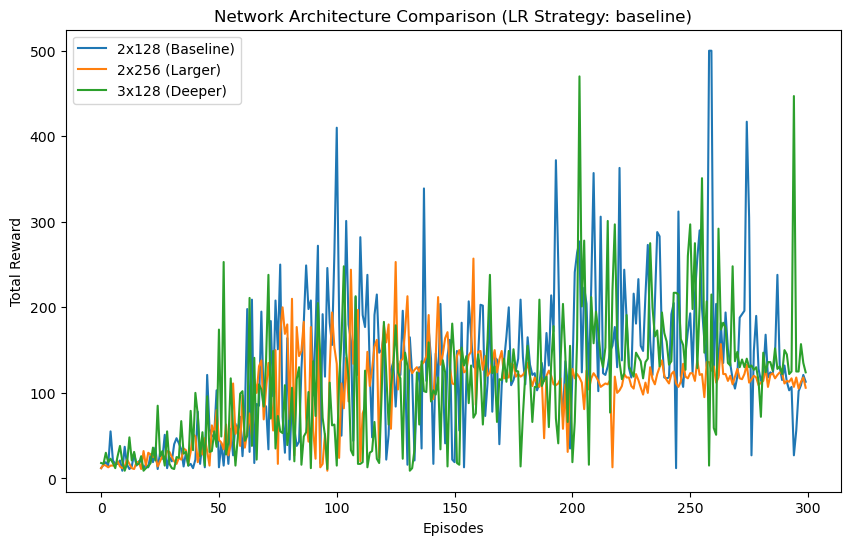

In [6]:
run_architecture_experiments(env, lr_strategy="baseline", num_episodes=300)

## Experience Replay Experiment

In [7]:
def run_experience_replay_experiments(env, num_episodes=300):
    """
    Compare Uniform vs. Prioritized Experience Replay.
    """
    results = {}
    print("\n=== Training with Uniform Experience Replay ===")
    agent_uniform = DQLAgentModular(env,
                                    hidden_layers=[128,128],
                                    initial_lr=0.0005,
                                    lr_strategy="baseline",  # fixed for this experiment
                                    replay_type="uniform",
                                    max_episodes=num_episodes)
    rewards_uniform = agent_uniform.train(num_episodes=num_episodes)
    results["Uniform"] = rewards_uniform
    
    print("\n=== Training with Prioritized Experience Replay ===")
    agent_per = DQLAgentModular(env,
                                hidden_layers=[128,128],
                                initial_lr=0.0005,
                                lr_strategy="baseline",
                                replay_type="per",
                                max_episodes=num_episodes)
    rewards_per = agent_per.train(num_episodes=num_episodes)
    results["PER"] = rewards_per
    
    plt.figure(figsize=(10,6))
    for key, rewards in results.items():
        plt.plot(rewards, label=key)
    plt.xlabel("Episodes")
    plt.ylabel("Total Reward")
    plt.title("Experience Replay Comparison: Uniform vs. PER")
    plt.legend()
    plt.show()


=== Training with Uniform Experience Replay ===
Episode 0/300, Reward: 10.0, Avg(10): 10.00, Eps: 0.990, LR: 0.000500
Episode 50/300, Reward: 55.0, Avg(10): 70.10, Eps: 0.599, LR: 0.000500
[baseline] Reducing LR to 0.000250
Episode 100/300, Reward: 207.0, Avg(10): 110.40, Eps: 0.362, LR: 0.000250
Episode 150/300, Reward: 324.0, Avg(10): 254.00, Eps: 0.219, LR: 0.000250
Episode 200/300, Reward: 219.0, Avg(10): 212.40, Eps: 0.133, LR: 0.000250
Episode 250/300, Reward: 121.0, Avg(10): 124.60, Eps: 0.080, LR: 0.000250

=== Training with Prioritized Experience Replay ===
Episode 0/300, Reward: 9.0, Avg(10): 9.00, Eps: 0.990, LR: 0.000500
Episode 50/300, Reward: 77.0, Avg(10): 42.40, Eps: 0.599, LR: 0.000500
Episode 100/300, Reward: 265.0, Avg(10): 161.10, Eps: 0.362, LR: 0.000500
Episode 150/300, Reward: 160.0, Avg(10): 191.40, Eps: 0.219, LR: 0.000500
Episode 200/300, Reward: 251.0, Avg(10): 248.20, Eps: 0.133, LR: 0.000500
Episode 250/300, Reward: 500.0, Avg(10): 256.80, Eps: 0.080, LR: 

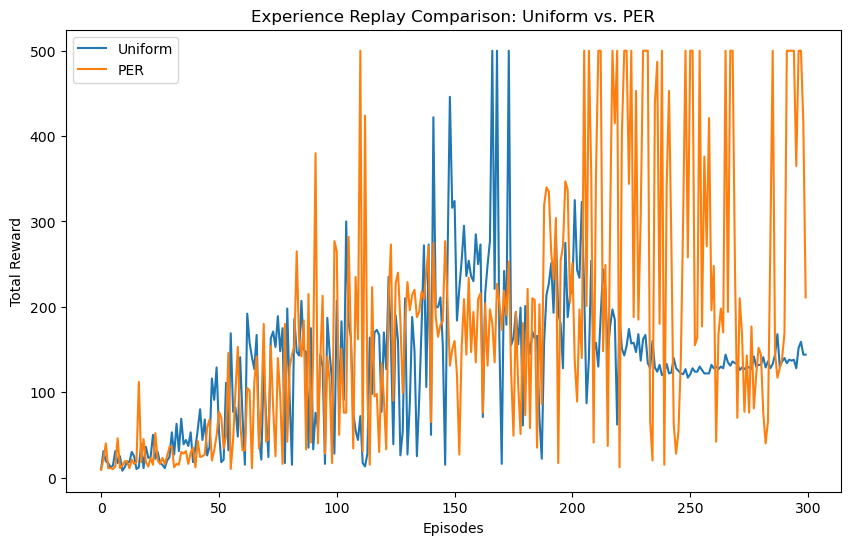

In [8]:
run_experience_replay_experiments(env, num_episodes=300)

## Train, test, evaluate and render fine tuned model

In [14]:
def run_finetune_pipeline():
    env = gym.make("CartPole-v1")
    agent = DQLAgentModular(env,
                            hidden_layers=[256,256],
                            initial_lr=0.0005,
                            lr_strategy="cosine_annealing",
                            replay_type="per",
                            max_episodes=1000)
    
    # 1. Training Analysis
    print("=== Training Analysis ===")
    training_rewards = agent.train(num_episodes=1000)
    plt.figure(figsize=(10,6))
    plt.plot(training_rewards)
    plt.xlabel("Episodes")
    plt.ylabel("Total Reward")
    plt.title("Training Rewards - 2x256, Cosine Annealing, PER")
    plt.grid(True)
    plt.show()
    print(f"Avg reward over last 50 episodes: {np.mean(training_rewards[-50:]):.2f}")
    print(f"Max reward during training: {np.max(training_rewards)}")
    
    # 2. Save Model
    model_filename = "dql_cartpole_finetuned.pth"
    torch.save(agent.q_network.state_dict(), model_filename)
    print(f"Model saved to {model_filename}")
    
    # 3. Test and Evaluate the Agent
    print("\n=== Testing the Agent (10 episodes) ===")
    for i in range(10):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]
        state = np.array(state, dtype=np.float32)
        total_reward = 0
        done = False
        while not done:
            action = agent.select_action(state, training=False)
            step_result = env.step(action)
            if len(step_result) == 4:
                next_state, reward, done, _ = step_result
            else:
                next_state, reward, done_, truncated, _ = step_result
                done = done_ or truncated
            state = np.array(next_state, dtype=np.float32)
            total_reward += reward
        print(f"Test Episode {i+1}, Total Reward: {total_reward}")
    
    print("\n=== Evaluating the Agent (100 episodes) ===")
    eval_rewards = []
    for _ in range(100):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]
        state = np.array(state, dtype=np.float32)
        total_reward = 0
        done = False
        while not done:
            action = agent.select_action(state, training=False)
            step_result = env.step(action)
            if len(step_result) == 4:
                next_state, reward, done, _ = step_result
            else:
                next_state, reward, done_, truncated, _ = step_result
                done = done_ or truncated
            state = np.array(next_state, dtype=np.float32)
            total_reward += reward
        eval_rewards.append(total_reward)
    avg_reward = np.mean(eval_rewards)
    std_reward = np.std(eval_rewards)
    median_reward = np.median(eval_rewards)
    success_rate = sum(r >= 195 for r in eval_rewards) / 100
    print("\n=== Evaluation Results ===")
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Median Reward: {median_reward:.2f}")
    print(f"Std Reward: {std_reward:.2f}")
    print(f"Success Rate (≥195): {success_rate:.2%}")
    
    # 4. Render One Episode (Record Video)
    print("\n=== Rendering One Episode ===")
    video_folder = "./video"
    if not os.path.exists(video_folder):
        os.makedirs(video_folder)
    env_video = gym.wrappers.RecordVideo(
        gym.make("CartPole-v1", render_mode="rgb_array"),
        video_folder=video_folder,
        episode_trigger=lambda episode_id: True,
        name_prefix="fine-tuned"
    )

    observation = env_video.reset()
    if isinstance(observation, tuple):
        observation = observation[0]
    observation = np.array(observation, dtype=np.float32)
    done = False
    cumulative_reward = 0
    steps = 0
    while not done:
        action = agent.select_action(observation, training=False)
        step_result = env_video.step(action)
        if len(step_result) == 4:
            next_obs, reward, done, _ = step_result
        else:
            next_obs, reward, done_, truncated, _ = step_result
            done = done_ or truncated
        observation = np.array(next_obs, dtype=np.float32)
        cumulative_reward += reward
        steps += 1
        time.sleep(0.01)
    env_video.close()
    print(f"Episode finished after {steps} steps, Total Reward: {cumulative_reward}")
    print(f"Video saved to: {os.path.abspath(video_folder)}")
    display(show_video(video_folder))

=== Training Analysis ===
Episode 0/1000, Reward: 30.0, Avg(10): 30.00, Eps: 0.990, LR: 0.000500
Episode 50/1000, Reward: 18.0, Avg(10): 64.80, Eps: 0.599, LR: 0.000382
Episode 100/1000, Reward: 182.0, Avg(10): 170.60, Eps: 0.362, LR: 0.000206
Episode 150/1000, Reward: 267.0, Avg(10): 209.90, Eps: 0.219, LR: 0.000280
Episode 200/1000, Reward: 124.0, Avg(10): 174.60, Eps: 0.133, LR: 0.000349
Episode 250/1000, Reward: 184.0, Avg(10): 281.90, Eps: 0.080, LR: 0.000010
Episode 300/1000, Reward: 188.0, Avg(10): 170.20, Eps: 0.049, LR: 0.000013
Episode 350/1000, Reward: 99.0, Avg(10): 98.40, Eps: 0.029, LR: 0.000050
Episode 400/1000, Reward: 150.0, Avg(10): 133.10, Eps: 0.018, LR: 0.000496
Episode 450/1000, Reward: 312.0, Avg(10): 197.50, Eps: 0.011, LR: 0.000308
Episode 500/1000, Reward: 149.0, Avg(10): 259.80, Eps: 0.010, LR: 0.000377
Episode 550/1000, Reward: 500.0, Avg(10): 401.90, Eps: 0.010, LR: 0.000441
Episode 600/1000, Reward: 128.0, Avg(10): 299.10, Eps: 0.010, LR: 0.000138
Episode 

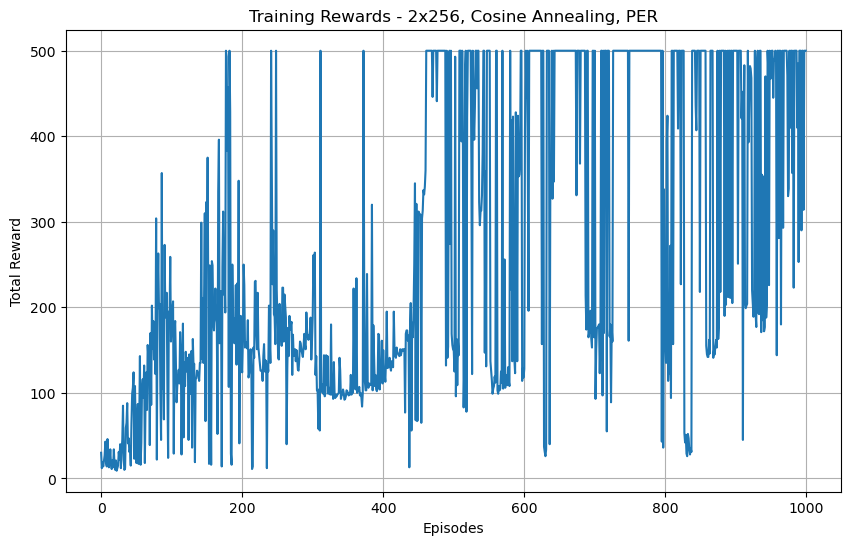

Avg reward over last 50 episodes: 442.80
Max reward during training: 500.0
Model saved to dql_cartpole_finetuned.pth

=== Testing the Agent (10 episodes) ===
Test Episode 1, Total Reward: 500.0
Test Episode 2, Total Reward: 253.0
Test Episode 3, Total Reward: 500.0
Test Episode 4, Total Reward: 500.0
Test Episode 5, Total Reward: 265.0
Test Episode 6, Total Reward: 271.0
Test Episode 7, Total Reward: 266.0
Test Episode 8, Total Reward: 264.0
Test Episode 9, Total Reward: 255.0
Test Episode 10, Total Reward: 500.0

=== Evaluating the Agent (100 episodes) ===

=== Evaluation Results ===
Average Reward: 364.24
Median Reward: 267.50
Std Reward: 120.55
Success Rate (≥195): 100.00%

=== Rendering One Episode ===
MoviePy - Building video C:\Users\User\Desktop\SCHOOL\Y2S2\SC3000 AI\SC3000_AI\cartpole_RL\video\fine-tuned-episode-0.mp4.
MoviePy - Writing video C:\Users\User\Desktop\SCHOOL\Y2S2\SC3000 AI\SC3000_AI\cartpole_RL\video\fine-tuned-episode-0.mp4



MoviePy - Done !
MoviePy - video ready C:\Users\User\Desktop\SCHOOL\Y2S2\SC3000 AI\SC3000_AI\cartpole_RL\video\fine-tuned-episode-0.mp4


Episode finished after 263 steps, Total Reward: 263.0
Video saved to: C:\Users\User\Desktop\SCHOOL\Y2S2\SC3000 AI\SC3000_AI\cartpole_RL\video


TypeError: show_video() takes 0 positional arguments but 1 was given

In [15]:
run_finetune_pipeline()